# Phase 4: Exploratory Data Analysis

Demographics, risk-factor distributions, discomfort prevalence. Figures saved to outputs/figures/.

## Step 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')

CWD = Path.cwd()
ROOT = CWD if (CWD / 'data').exists() else CWD.parent
df   = pd.read_csv(ROOT / 'data' / 'processed' / 'model_ready.csv')
risk = pd.read_csv(ROOT / 'data' / 'processed' / 'risk_profile.csv')
FIGS = ROOT / 'outputs' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

print('model_ready :', df.shape)
print('risk_profile:', risk.shape)

model_ready : (182, 67)
risk_profile: (182, 14)


## Step 1 — Quick overview

In [2]:
assert len(df) == len(risk) == 182

risk_cols = ['force_risk', 'repetition_risk', 'duration_risk',
             'vibration_risk', 'contact_stress_risk', 'posture_risk']
{c: risk[c].value_counts().to_dict() for c in risk_cols}

{'force_risk': {'Low': 90, 'Medium': 57, 'High': 35},
 'repetition_risk': {'Medium': 84, 'Low': 79, 'High': 19},
 'duration_risk': {'High': 89, 'Medium': 56, 'Low': 37},
 'vibration_risk': {'Medium': 68, 'Low': 67, 'High': 47},
 'contact_stress_risk': {'Low': 68, 'Medium': 58, 'High': 56},
 'posture_risk': {'Not Assessed': 182}}

## Step 2 — Demographics

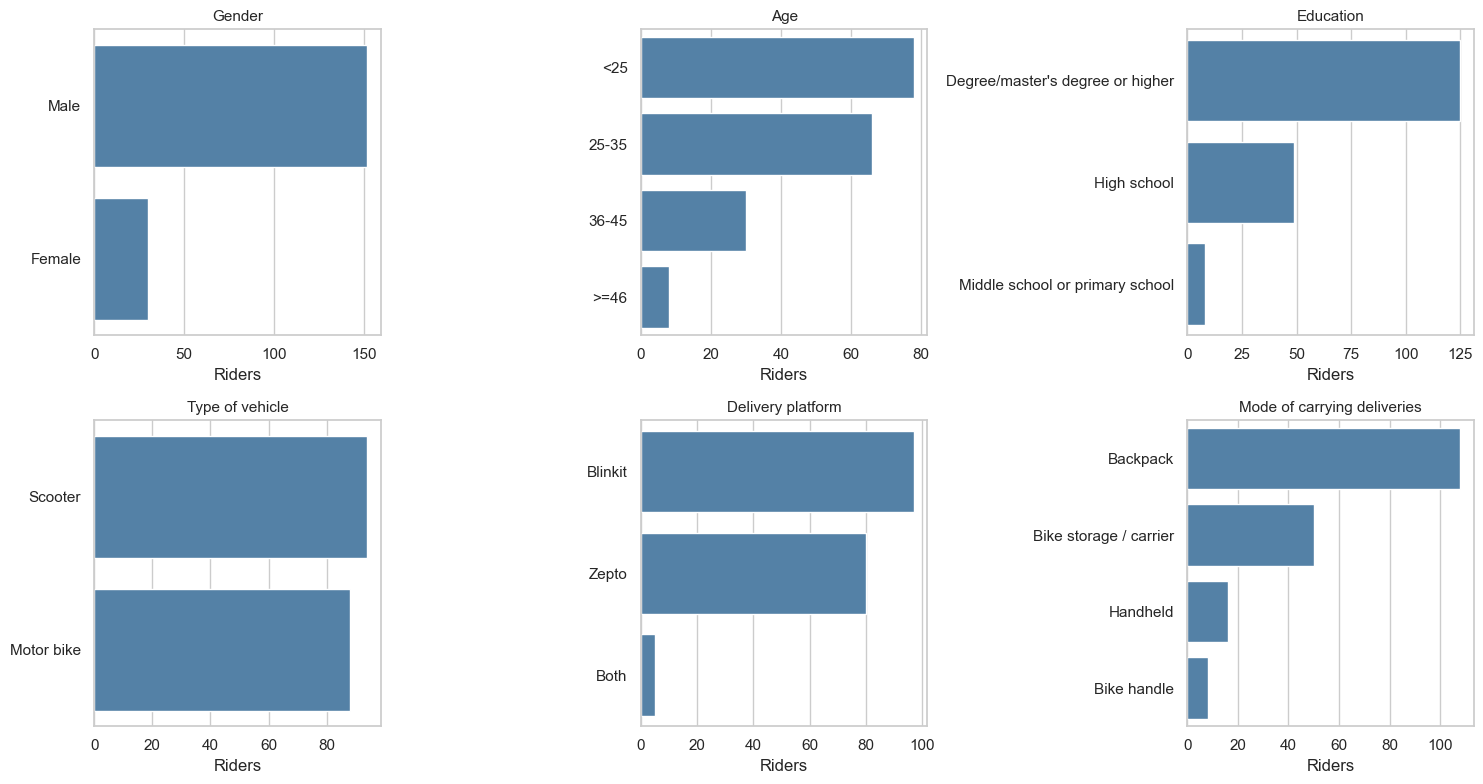

In [3]:
demo_cols = ['Gender', 'Age', 'Education',
             'Type of vehicle', 'Delivery platform', 'Mode of carrying deliveries']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, demo_cols):
    vc = df[c].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=ax, color='steelblue')
    ax.set_title(c, fontsize=11)
    ax.set_xlabel('Riders')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGS / 'demographics.png', dpi=120, bbox_inches='tight')
plt.show()